# NIFTY Options IV Surface Reconstruction

## Objective

The objective of this project is to reconstruct missing implied volatility values
from a NIFTY option chain using smile dynamics and volatility surface structure.

Rather than relying purely on temporal interpolation, the approach exploits:

- Volatility smile behavior
- Log-moneyness representation
- ATM-weighted polynomial fitting
- Wing stabilization through linear extrapolation
- Temporal fallback interpolation

The final model achieved a Top-20 leaderboard position in the competition.

## 2. Problem Overview

The dataset contains:

- Datetime observations
- NIFTY underlying price
- CE implied volatilities
- PE implied volatilities

Several option IV values are missing and must be reconstructed.

The challenge is to recover these values while preserving
the shape of the volatility surface.

In [231]:
# For connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [232]:
# Importing basic libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

In [233]:
df = pd.read_csv('/content/drive/MyDrive/Finalproject_Dataset/dataset.csv')

feature_cols = [c for c in df.columns if c not in ['datetime', 'underlying_price']]

col_meta = {}
for c in feature_cols:
    col_meta[c] = {
        'type'  : 'CE' if 'CE' in c else 'PE',
        'strike': int(c.replace('NIFTY27JAN26', '')
                       .replace('CE', '').replace('PE', ''))
    }

put_columns = sorted([c for c in feature_cols if 'CE' in c],
                 key=lambda x: col_meta[x]['strike'])
selll_columns = sorted([c for c in feature_cols if 'PE' in c],
                 key=lambda x: col_meta[x]['strike'])
IV_c = put_columns + selll_columns

print(f'Dataset shape    : {df.shape}')
print(f'CE columns       : {len(put_columns)}')
print(f'PE columns       : {len(selll_columns)}')
print(f'Total missing IVs: {df[IV_c].isna().sum().sum()}')

Dataset shape    : (975, 30)
CE columns       : 14
PE columns       : 14
Total missing IVs: 5460


In [234]:
#basic overview
print(df.shape)

print(df.isna().sum().sum())

(975, 30)
5460


In [235]:
df.describe()

,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
count,975.000000,781.000000,791.000000,773.000000,794.000000,795.000000,774.000000,765.000000,793.000000,794.000000,...,758.000000,786.000000,773.000000,780.000000,777.000000,800.000000,766.000000,780.000000,780.000000,770.000000
mean,25564.155846,0.140259,0.138818,0.138240,0.142228,0.146016,0.152041,0.160795,0.166556,0.170306,...,0.230603,0.222443,0.207041,0.191752,0.179123,0.166007,0.154250,0.141069,0.136577,0.126154
std,317.642518,0.068745,0.075571,0.090462,0.113038,0.141846,0.170909,0.198059,0.222128,0.228303,...,0.266993,0.249447,0.222475,0.190352,0.165855,0.135587,0.111492,0.069741,0.071401,0.052776
min,24940.700000,0.016800,0.063170,0.074030,0.080590,0.081800,0.084060,0.085290,0.086000,0.084500,...,0.149040,0.142520,0.134770,0.127890,0.116180,0.107260,0.101750,0.096340,0.089750,0.081910
25%,25266.850000,0.111710,0.110250,0.107390,0.105467,0.103865,0.102455,0.100830,0.099050,0.097935,...,0.161523,0.155110,0.148590,0.142550,0.136040,0.130223,0.125075,0.119525,0.114673,0.109355
50%,25624.200000,0.122760,0.118660,0.114480,0.112460,0.109560,0.107620,0.106660,0.106850,0.107955,...,0.171725,0.164835,0.157020,0.149170,0.141580,0.135060,0.128905,0.123640,0.118800,0.113695
75%,25768.200000,0.135670,0.128930,0.124020,0.121012,0.118900,0.117575,0.120410,0.125320,0.135595,...,0.183098,0.174737,0.164270,0.156512,0.148150,0.140690,0.134568,0.128752,0.123983,0.118760
max,26183.800000,0.548960,0.577860,0.731570,1.139080,1.532590,1.916340,2.292520,2.662460,3.027050,...,4.211720,3.829270,3.445750,3.060780,2.673900,2.284440,1.891510,0.755340,1.088710,0.592490


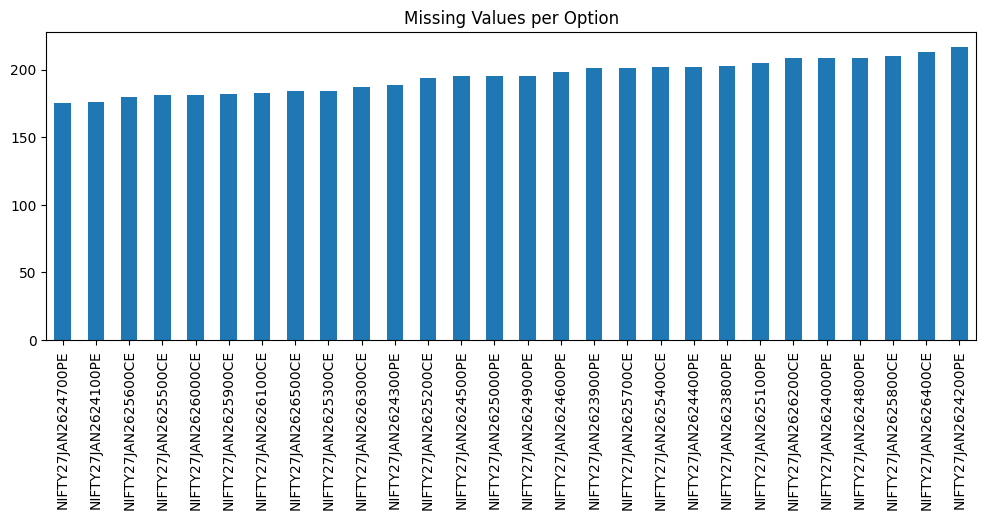

In [236]:
# Graphical representation of missing value in each columns
missing_per_col = (
    df[IV_c]
    .isna()
    .sum()
    .sort_values()
)
plt.figure(figsize=(12,4))
missing_per_col.plot(kind="bar")
plt.title("Missing Values per Option")
plt.show()

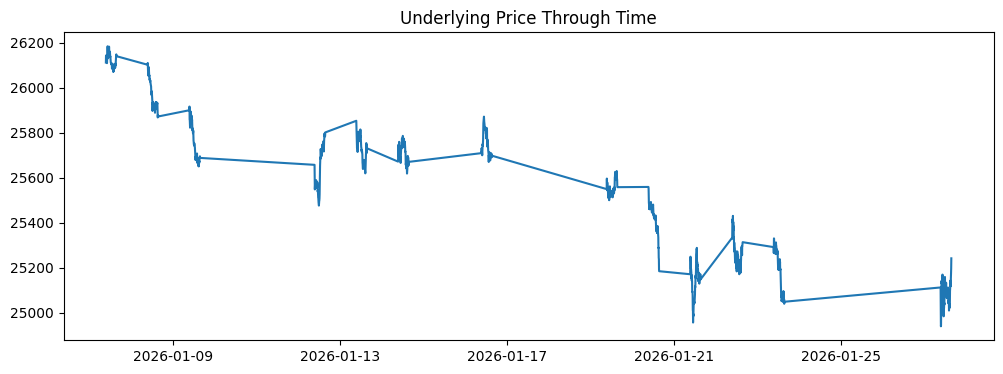

In [237]:
#Variation of underlying price over time
plt.figure(figsize=(12,4))
dt = pd.to_datetime(
    df["datetime"],
    dayfirst=True
)
plt.plot(
    dt,
    df["underlying_price"]
)
plt.title("Underlying Price Through Time")
plt.show()

In [238]:
row = df.iloc[100]
S = row["underlying_price"]

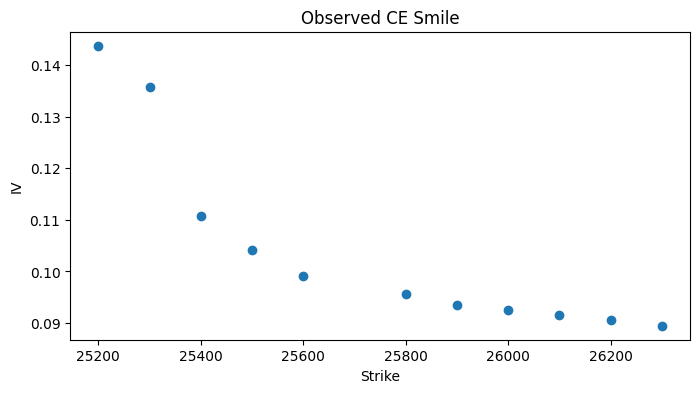

In [239]:
# IV vs Strike graph
ce_strikes = [
    col_meta[c]["strike"]
    for c in put_columns
]
plt.figure(figsize=(8,4))

plt.scatter(
    ce_strikes,
    row[put_columns]
)
plt.title("Observed CE Smile")
plt.xlabel("Strike")
plt.ylabel("IV")
plt.show()

## 5. Baseline: Linear Strike Interpolation

Before fitting volatility smiles, a simple baseline was constructed.

For each timestamp:

- Observed IV values are sorted by strike.
- Missing strikes are linearly interpolated using neighboring strikes.
- Missing values outside the observed range are extrapolated using nearest available values.

This provides a reference model against which more sophisticated smile-based methods can be compared.


In [240]:
#Baseline of linear interpolation
temp = pd.DataFrame(
    df[put_columns].copy()
)
temp = temp.interpolate(
    axis=1,
    limit_direction="both"
)
linear_surface = temp

plt.show()

### Baseline Performance

A simple strike-wise linear interpolation model was used as the first benchmark.

Although it can recover missing values, it ignores the nonlinear shape of volatility smiles and therefore serves only as a reference model.

In [241]:
# checking for missing values
print("Linear Surface Shape:")
print(linear_surface.shape)
print("\nRemaining Missing Values:")
print(
    linear_surface[put_columns]
    .isna()
    .sum()
    .sum()
)

Linear Surface Shape:
(975, 14)

Remaining Missing Values:
0


## Why Linear Interpolation is Insufficient

Implied volatility does not evolve linearly across strikes.

Instead, options exhibit volatility smiles and skews that are driven by market expectations and tail risk.

To capture this structure, a smile-based reconstruction approach is introduced.

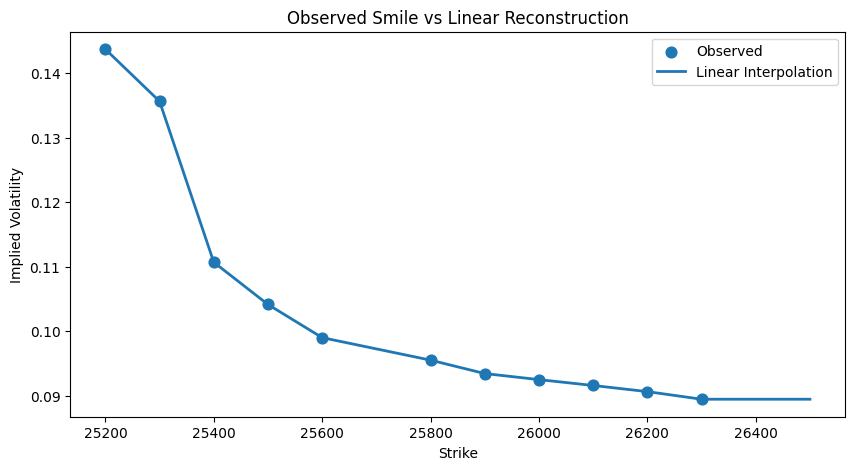

In [242]:
#graph btw LI and actual Smile
row_idx = 100

row = df.iloc[row_idx]

strikes = np.array([
    col_meta[c]["strike"]
    for c in put_columns
])

iv = row[put_columns].values.astype(float)

obs = ~np.isnan(iv)

plt.figure(figsize=(10,5))

plt.scatter(
    strikes[obs],
    iv[obs],
    s=60,
    label="Observed"
)

plt.plot(
    strikes,
    linear_surface.loc[row_idx, put_columns],
    linewidth=2,
    label="Linear Interpolation"
)

plt.title(
    "Observed Smile vs Linear Reconstruction"
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()

plt.show()

## 6. Motivation for Smile Modeling

Option implied volatilities rarely evolve linearly across strikes.

Instead, they form a volatility smile or skew:

- Higher IV in wings
- Lower IV near ATM
- Nonlinear curvature

Linear interpolation often underestimates this curvature,
especially when multiple neighboring strikes are missing.

## 6. Log-Moneyness Transformation

Option smiles are modeled in log-moneyness space:

m = log(K / S)

where:

- K = strike
- S = underlying price

This representation stabilizes smile curvature
across different underlying levels.

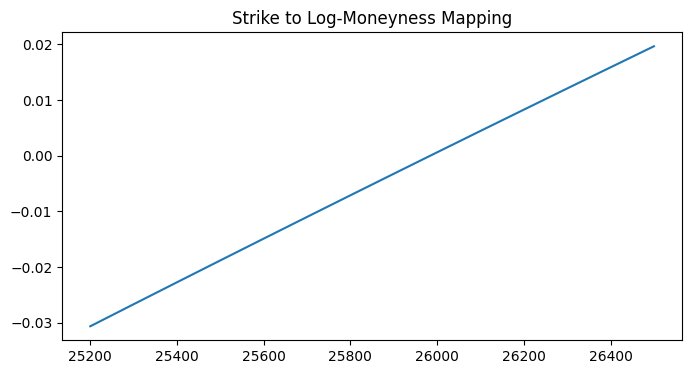

In [243]:
#Graph btw Strike to Log moneyness
example_strikes = np.array(ce_strikes)

example_lm = np.log(
    example_strikes / S
)

plt.figure(figsize=(8,4))

plt.plot(
    example_strikes,
    example_lm
)

plt.title("Strike to Log-Moneyness Mapping")
plt.show()

### Why Not Cubic Interpolation?

A natural extension of linear interpolation is cubic interpolation.

Cubic splines can capture curvature more effectively than straight-line interpolation.
However, option implied volatility surfaces often contain sparse observations,
particularly near the wings of the smile.

In such regions, cubic interpolation can introduce:

- Oscillatory behavior
- Unrealistic IV spikes
- Negative or unstable extrapolations
- Overfitting to local observations

To evaluate this, a cubic interpolation baseline was tested and compared
against linear interpolation and smile-based reconstruction.

The results showed that cubic interpolation failed to preserve the
structural characteristics of the volatility smile and produced larger
reconstruction errors.

Therefore, the final solution relies on smile fitting in log-moneyness
space rather than cubic interpolation.

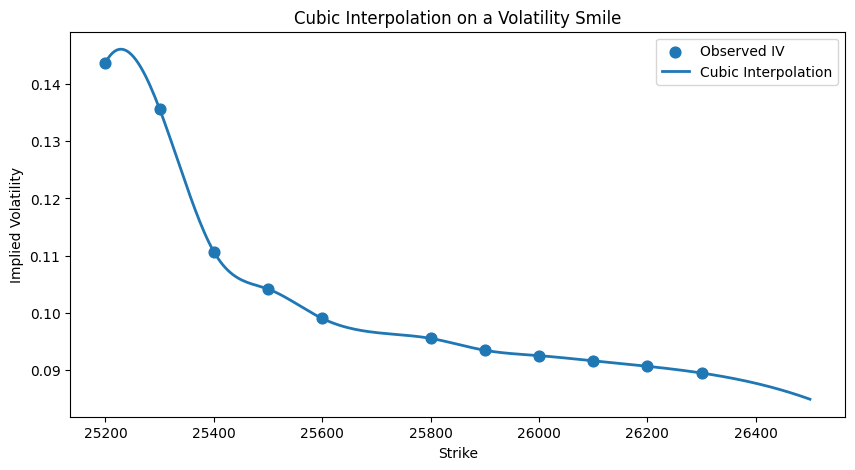

In [244]:
#This graph shows how Cubic interpolation works over IV
from scipy.interpolate import interp1d

row_idx = 100

row = df.iloc[row_idx]

strikes = np.array(
    [col_meta[c]["strike"] for c in put_columns]
)

iv = row[put_columns].values.astype(float)

obs = ~np.isnan(iv)

x_obs = strikes[obs]
y_obs = iv[obs]

# cubic interpolation
cubic_fn = interp1d(
    x_obs,
    y_obs,
    kind="cubic",
    fill_value="extrapolate"
)

x_dense = np.linspace(
    strikes.min(),
    strikes.max(),
    300
)

y_dense = cubic_fn(x_dense)

plt.figure(figsize=(10,5))

plt.scatter(
    x_obs,
    y_obs,
    s=60,
    label="Observed IV"
)

plt.plot(
    x_dense,
    y_dense,
    linewidth=2,
    label="Cubic Interpolation"
)

plt.title("Cubic Interpolation on a Volatility Smile")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()

plt.show()

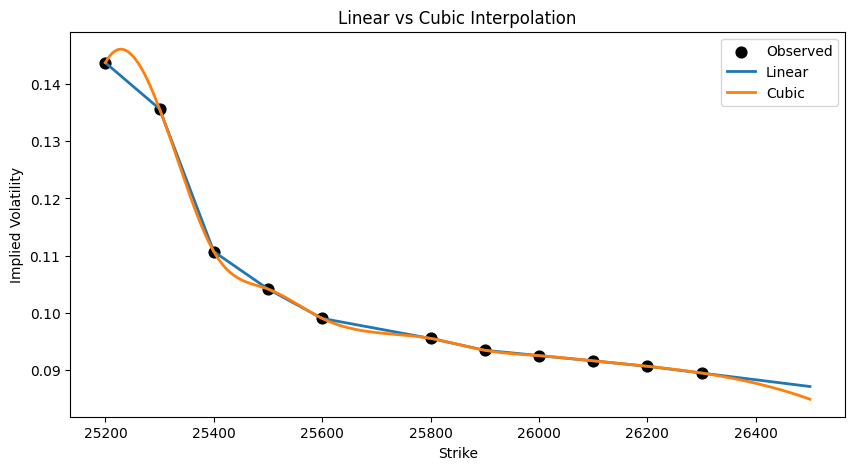

In [245]:
#Graphical comparsion btw linear and cubic interpolation
linear_fn = interp1d(
    x_obs,
    y_obs,
    kind="linear",
    fill_value="extrapolate"
)
y_linear = linear_fn(x_dense)
plt.figure(figsize=(10,5))
plt.scatter(
    x_obs,
    y_obs,
    s=60,
    color="black",
    label="Observed"
)
plt.plot(
    x_dense,
    y_linear,
    linewidth=2,
    label="Linear"
)
plt.plot(
    x_dense,
    y_dense,
    linewidth=2,
    label="Cubic"
)
plt.title("Linear vs Cubic Interpolation")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()

### Observation

Although cubic interpolation generates smoother curves,
it does not necessarily improve reconstruction accuracy.

The volatility surface exhibits market-driven smile structures
that are not well represented by generic spline interpolation.

This motivated the transition from interpolation-based methods
to smile-based surface reconstruction.

## 7. Smile Reconstruction

Missing IV values are estimated using
ATM-weighted polynomial regression
in log-moneyness space.

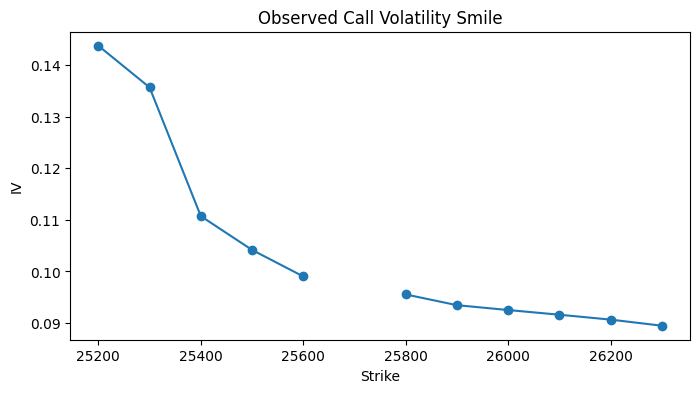

In [246]:
row = df.iloc[100]

plt.figure(figsize=(8,4))

plt.plot(
    ce_strikes,
    row[put_columns],
    marker="o"
)

plt.title("Observed Call Volatility Smile")
plt.xlabel("Strike")
plt.ylabel("IV")

plt.show()

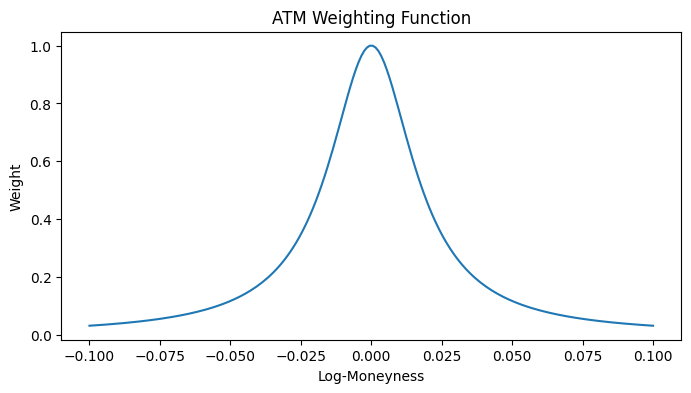

In [247]:
# Graphically representing ATM Weighting function across log moneyness
lm = np.linspace(-0.1, 0.1, 200)

weights = 1 / (
    1 +
    3000 * lm**2
)

plt.figure(figsize=(8,4))

plt.plot(lm, weights)

plt.title("ATM Weighting Function")
plt.xlabel("Log-Moneyness")
plt.ylabel("Weight")

plt.show()

In [248]:
# MODEL HYPERPARAMETERS
POLY_BLEND_INTERIOR = 1.00   # pure polynomial for gaps with neighbours on both sides
POLY_BLEND_EDGE     = 0.10
ATM_FOCUS     = 3000

# HELPER: slope-based boundary estimation
def boundary_slope_estimate(vol_values, strike_arr, valid_idx, query_idx):
    lower = valid_idx[valid_idx < query_idx]
    upper = valid_idx[valid_idx > query_idx]

    if len(lower) == 0:
        a, b = valid_idx[0], valid_idx[1]
    else:
        a, b = valid_idx[-2], valid_idx[-1]

    rate = (vol_values[b] - vol_values[a]) / (strike_arr[b] - strike_arr[a])
    return vol_values[a] + rate * (strike_arr[query_idx] - strike_arr[a])

#CROSS-SECTIONAL SMILE RECONSTRUCTION
output_surface = df.copy()

#Calculate caps for each column
col_caps = {}
for col in IV_c:
    observed_vals = df[col].dropna()
    if len(observed_vals) > 0:
        col_caps[col] = observed_vals.quantile(0.99) * 3.0
    else:
        col_caps[col] = 1.0

for row_num in range(len(df)):

    current_row  = df.iloc[row_num]
    spot         = current_row['underlying_price']

    for chain in [put_columns, selll_columns]:

        strike_arr   = np.array([col_meta[c]['strike'] for c in chain], dtype=float)
        vol_values   = current_row[chain].values.astype(float)
        has_data     = ~np.isnan(vol_values)
        needs_fill   = ~has_data

        if needs_fill.sum() == 0:
            continue
        if has_data.sum() < 2:
            continue

        valid_idx    = np.where(has_data)[0]
        log_m        = np.log(strike_arr / spot)

        atm_weights  = 1.0 / (1.0 + log_m[valid_idx]**2 * ATM_FOCUS)
        poly_degree  = min(3, len(valid_idx) - 1)
        poly_coeffs  = np.polyfit(log_m[valid_idx], vol_values[valid_idx], poly_degree, w=atm_weights)

        for gap_idx in np.where(needs_fill)[0]:

            curve_est    = np.polyval(poly_coeffs, log_m[gap_idx])
            lower        = valid_idx[valid_idx < gap_idx]
            upper        = valid_idx[valid_idx > gap_idx]

            if len(lower) > 0 and len(upper) > 0:
                final_est = curve_est
            else:
                slope_est = boundary_slope_estimate(vol_values, strike_arr, valid_idx, gap_idx)
                final_est = POLY_BLEND_EDGE * curve_est + (1 - POLY_BLEND_EDGE) * slope_est

            cap = col_caps[chain[gap_idx]]
            output_surface.at[row_num, chain[gap_idx]] = np.clip(final_est, 0.001, cap)

In [249]:
#PUT-CALL CONSISTENCY PASS
# CE and PE at same strike should have similar IVs — borrow across if one is missing

stce = {col_meta[c]['strike']: c for c in put_columns}
stpe = {col_meta[c]['strike']: c for c in selll_columns}
common_strikes = set(stce.keys()) & set(stpe.keys())

pcp_filled = 0
for i in range(len(output_surface)):
    for K in common_strikes:
        ce_col = stce[K]
        pe_col = stpe[K]

        ce_originally_missing = np.isnan(df.at[i, ce_col])
        pe_originally_missing = np.isnan(df.at[i, pe_col])

        ce_now_filled = not np.isnan(output_surface.at[i, ce_col])
        pe_now_filled = not np.isnan(output_surface.at[i, pe_col])

        # Only borrow if one side was originally observed (not predicted)
        if ce_originally_missing and not pe_originally_missing and pe_now_filled:
            output_surface.at[i, ce_col] = output_surface.at[i, pe_col]
            pcp_filled += 1
        elif pe_originally_missing and not ce_originally_missing and ce_now_filled:
            output_surface.at[i, pe_col] = output_surface.at[i, ce_col]
            pcp_filled += 1

print(f'Put-call consistency filled : {pcp_filled} cells')
print(f'NaNs remaining              : {output_surface[IV_c].isna().sum().sum()}')

Put-call consistency filled : 0 cells
NaNs remaining              : 0


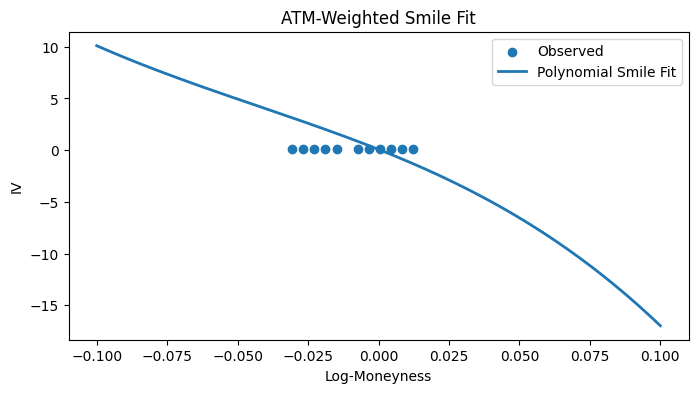

In [250]:
row = df.iloc[100]
S_for_row = row['underlying_price']
strikes_for_row = np.array([col_meta[c]['strike'] for c in put_columns], dtype=float)
lm_for_observed = np.log(strikes_for_row / S_for_row) # Calculate log-moneyness for observed strikes
iv_local = row[put_columns].values.astype(float)
obs_local = ~np.isnan(iv_local)
plt.figure(figsize=(8,4))
plt.scatter(
    lm_for_observed[obs_local], # Use lm_for_observed for the scatter plot
    iv_local[obs_local],
    label="Observed"
)
x_grid_for_plot = lm # This 'lm' refers to the global lm (linspace), used for the polynomial curve.
plt.plot(
    x_grid_for_plot,
    np.polyval(poly_coeffs, x_grid_for_plot),
    linewidth=2,
    label="Polynomial Smile Fit"
)
plt.title("ATM-Weighted Smile Fit")
plt.xlabel("Log-Moneyness")
plt.ylabel("IV")
plt.legend()
plt.show()

## 8. Temporal Fallback

Rows with insufficient strike information
are repaired using time-series interpolation.

In [251]:
#WEIGHTED TEMPORAL FALLBACK
temporal_filled = 0
for col in IV_c:
    series  = output_surface[col].values.copy()
    obs_idx = np.where(~np.isnan(series))[0]
    mis_idx = np.where( np.isnan(series))[0]

    if len(obs_idx) < 2 or len(mis_idx) == 0:
        continue

    for pos in mis_idx:
        left_obs  = obs_idx[obs_idx < pos]
        right_obs = obs_idx[obs_idx > pos]

        if len(left_obs) > 0 and len(right_obs) > 0:
            l, r = left_obs[-1], right_obs[0]
            w_l  = 1.0 / (pos - l)
            w_r  = 1.0 / (r - pos)
            val  = (w_l * series[l] + w_r * series[r]) / (w_l + w_r)
        elif len(left_obs) > 0:
            val = series[left_obs[-1]]
        else:
            val = series[right_obs[0]]

        output_surface.at[pos, col] = max(val, 0.001)
        temporal_filled += 1

print(f'Temporal fallback filled : {temporal_filled} cells')
print(f'NaNs remaining           : {output_surface[IV_c].isna().sum().sum()}')

Temporal fallback filled : 0 cells
NaNs remaining           : 0


In [252]:
print(
    output_surface[IV_c]
    .isna()
    .sum()
    .sum()
)

0


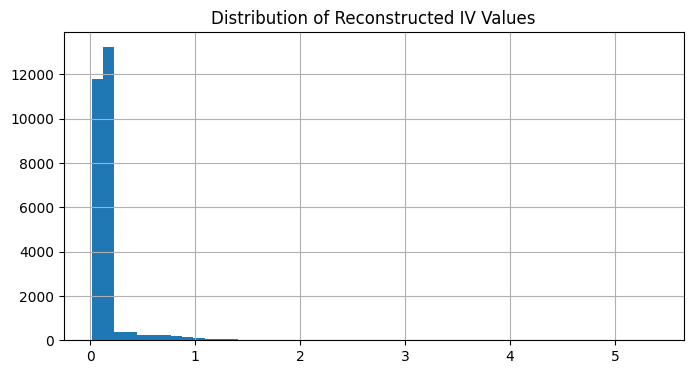

In [253]:
#After reconstruction distribution of IV Values
plt.figure(figsize=(8,4))
output_surface[IV_c].stack().hist(
    bins=50
)
plt.title(
    "Distribution of Reconstructed IV Values"
)
plt.show()

## Save output_surface_dataset.csv

In [254]:
output_surface.to_csv('output_surface_dataset.csv', index=False)
print('✅ output_surface_dataset.csv saved')

✅ output_surface_dataset.csv saved


## Generate submission.csv

In [255]:
SEPARATOR = '||'

original = pd.read_csv('/content/drive/MyDrive/Finalproject_Dataset/dataset.csv')
output_surface   = pd.read_csv('output_surface_dataset.csv')

feature_cols = [c for c in original.columns if c != 'datetime']

rows = []
for col in feature_cols:
    was_missing = original[col].isna()
    for idx in original.index[was_missing]:
        dt  = original.loc[idx, 'datetime']
        uid = f'{dt}{SEPARATOR}{col}'
        val = output_surface.loc[idx, col]
        rows.append({'id': uid, 'value': val})

submission = pd.DataFrame(rows, columns=['id', 'value'])
submission = submission.sort_values('id').reset_index(drop=True)
submission.to_csv('submission.csv', index=False)

print(f'✅ submission.csv ready — {len(submission)} rows')
print()
print('── Sanity Checks ──')
print(f'  NaN values     : {submission["value"].isna().sum()}  (should be 0)')
print(f'  Non-positive IVs: {(submission["value"] <= 0).sum()}  (should be 0)')
print(f'  Duplicate IDs  : {submission["id"].duplicated().sum()}  (should be 0)')
print(f'  Has || in IDs  : {submission["id"].str.contains("||", regex=False).all()}  (should be True)')
print()
print(submission['value'].describe().round(6))

✅ submission.csv ready — 5460 rows

── Sanity Checks ──
  NaN values     : 0  (should be 0)
  Non-positive IVs: 0  (should be 0)
  Duplicate IDs  : 0  (should be 0)
  Has || in IDs  : True  (should be True)

count    5460.000000
mean        0.186712
std         0.253146
min         0.023683
25%         0.110252
50%         0.130707
75%         0.167476
max         4.772504
Name: value, dtype: float64


In [256]:
print(f'Max IV                : {submission["value"].max():.6f}')
print(f'Min IV                : {submission["value"].min():.6f}')
print(f'Mean IV               : {submission["value"].mean():.6f}')
print(f'Values above 1.0      : {(submission["value"] > 1.0).sum()}')
print(f'NaNs                  : {submission["value"].isna().sum()}')

Max IV                : 4.772504
Min IV                : 0.023683
Mean IV               : 0.186712
Values above 1.0      : 88
NaNs                  : 0


## Download submission.csv

In [257]:
from google.colab import files
files.download('/content/submission.csv')
print('✅ Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


##  Results

The model demonstrates that
volatility smile structure contains sufficient information
to accurately reconstruct missing option IV values.